# 06 - Sélection de features par permutation importance

**Objectif :** réduire le modèle LightGBM de 119 features à un sous-ensemble de k features (k entre 1 et 20)
qui maximise l'AUC en validation croisée, afin de simplifier l'API de production.

**Méthode :** permutation importance — on mesure la dégradation de l'AUC quand on permute aléatoirement
les valeurs d'une feature. Si la performance chute, la feature est importante. C'est plus fiable que
l'importance interne des arbres (qui surestime les variables à haute cardinalité).

**Plan :**
1. Chargement des données + même split que notebook 03
2. Calcul de la permutation importance sur le modèle optimisé (notebook 04)
3. Boucle k = 1 à 20 : AUC CV pour chaque sous-ensemble top-k
4. Visualisation et choix du k optimal
5. Entraînement et évaluation du modèle final
6. Logging MLflow + comparaison avec le modèle complet

In [ ]:
import re
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.lightgbm

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

## 1. Chargement des données et split

On reproduit exactement le split du notebook 03 (`random_state=42`, `test_size=0.2`, `stratify=y`)
pour que les métriques soient comparables entre les deux modèles.

On exclut `SK_ID_CURR` : c'est un identifiant client sans valeur prédictive.
Il était resté par inadvertance dans le jeu d'entraînement du notebook 03.

In [10]:
# Chargement du dataset final (produit par notebook 02)
df = pd.read_csv('../data/processed/dataset_final.csv')

# On retire TARGET (cible) et SK_ID_CURR (identifiant, sans valeur prédictive)
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

# Nettoyage des noms de colonnes : LightGBM n'accepte pas les caractères spéciaux
# (virgules, barres obliques, espaces...) → on les remplace par des underscores
X.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X.columns]

# Même split que notebook 03 : 80% train, 20% test, stratifié sur TARGET
# random_state=42 garantit exactement les mêmes individus dans chaque split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Même CV que notebook 03 : 5 folds stratifiés, shuffle pour éviter les biais d'ordre
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train : {X_train.shape} — défauts : {y_train.mean()*100:.2f}%')
print(f'Test  : {X_test.shape}  — défauts : {y_test.mean()*100:.2f}%')
print(f'Features disponibles : {X.shape[1]}')

Train : (246008, 119) — défauts : 8.07%
Test  : (61503, 119)  — défauts : 8.07%
Features disponibles : 119


## 2. Features sélectionnées (ranking SHAP du notebook 05)

Dans le notebook 05, on a calculé les valeurs SHAP sur 5000 clients avec `TreeExplainer`.
L'importance globale est `mean(|SHAP value|)` : impact moyen de chaque feature sur la prédiction.

On réutilise directement le top-20 obtenu — pas besoin de recalculer SHAP ici.
Ces 20 features constituent l'espace de recherche pour la boucle k = 1 à 20.

| Rang | Feature | mean(\|SHAP\|) |
|------|---------|----------------|
| 1 | EXT_SOURCE_2 | 0.315 |
| 2 | EXT_SOURCE_3 | 0.283 |
| 3 | EXT_SOURCE_1 | 0.164 |
| 4 | RATIO_CREDIT_BIEN | 0.138 |
| 5 | INSTALL_MANQUE_MOYEN | 0.135 |
| 6 | CODE_GENDER_M | 0.124 |
| 7 | DAYS_EMPLOYED | 0.113 |
| 8 | AMT_ANNUITY | 0.112 |
| 9 | FLAG_OWN_CAR | 0.094 |
| 10 | CC_SOLDE_MOYEN | 0.092 |
| 11 | BUREAU_JOURS_MOYEN | 0.086 |
| 12 | POS_NB_MOIS | 0.085 |
| 13 | AGE | 0.081 |
| 14 | AMT_CREDIT | 0.080 |
| 15 | BUREAU_DETTE_MOYENNE | 0.078 |
| 16 | NAME_EDUCATION_TYPE_Higher_education | 0.077 |
| 17 | PREV_NB_REFUSEES | 0.073 |
| 18 | NAME_FAMILY_STATUS_Married | 0.067 |
| 19 | DAYS_ID_PUBLISH | 0.054 |
| 20 | BUREAU_NB_ACTIFS | 0.053 |

In [ ]:
# Top 20 features selon SHAP (notebook 05) — liste en dur, ordre d'importance décroissante
# Cet ordre est crucial : la boucle prend features_ordonnees[:k], donc le rang compte
features_ordonnees = [
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'EXT_SOURCE_1',
    'RATIO_CREDIT_BIEN',
    'INSTALL_MANQUE_MOYEN',
    'CODE_GENDER_M',
    'DAYS_EMPLOYED',
    'AMT_ANNUITY',
    'FLAG_OWN_CAR',
    'CC_SOLDE_MOYEN',
    'BUREAU_JOURS_MOYEN',
    'POS_NB_MOIS',
    'AGE',
    'AMT_CREDIT',
    'BUREAU_DETTE_MOYENNE',
    'NAME_EDUCATION_TYPE_Higher_education',
    'PREV_NB_REFUSEES',
    'NAME_FAMILY_STATUS_Married',
    'DAYS_ID_PUBLISH',
    'BUREAU_NB_ACTIFS',
]

print(f'{len(features_ordonnees)} features prêtes pour la boucle k = 1 à 20')

**Analyse :** L'importance SHAP chute fortement après les 3 sources externes de crédit
(`EXT_SOURCE_1/2/3`, mean|SHAP| > 0.16), puis décroît plus graduellement de la position 4 à 20
(de 0.14 à 0.05). Il n'y a pas de rupture nette — chaque feature apporte une contribution modeste
mais non nulle. Ce pattern va se confirmer dans la boucle k : on s'attend à une courbe AUC
sans plateau franc, qui monte jusqu'à k=20.

## 3. Recherche du k optimal (boucle k = 1 à 20)

Les 20 features SHAP sont maintenant classées par importance décroissante.
Pour chaque k, on prend les top-k features et on mesure l'AUC CV avec un LightGBM
entraîné sur ces k features uniquement.

**Hyperparamètres :** ceux du modèle optimisé (notebook 04) pour une comparaison équitable.
On veut isoler l'effet de la réduction de features, pas un changement d'hyperparamètres.

**Seuil de comparaison :** on utilise 0.5 ici (pas 0.54) car on compare les k entre eux
à seuil constant. Le seuil métier optimal sera recalculé pour le modèle final en section 5.

> Cette boucle peut prendre 10-20 minutes (20 k × 5 folds × LightGBM optimisé).

In [14]:
# Hyperparamètres du modèle optimisé (notebook 04, run MLflow)
# On les réutilise pour une comparaison équitable avec le modèle à 119 features
params_optimises = {
    'learning_rate'    : 0.19341661535922583,
    'max_depth'        : 3,
    'min_child_samples': 75,
    'n_estimators'     : 237,
    'num_leaves'       : 85,
    'class_weight'     : 'balanced',  # compense le déséquilibre 8%/92%
    'random_state'     : 42,
    'n_jobs'           : -1,
    'verbosity'        : -1
}

resultats_k = []  # stocke (k, auc_cv, sensibilite_cv, specificite_cv)

print(f'Boucle sur k = 1 à 20...')
print(f'{"k":>3}  {"AUC CV":>8}  {"Sensib. CV":>10}  {"Specif. CV":>10}')
print('-' * 40)

for k in range(1, 21):
    # Sélection des top-k features selon le ranking de permutation importance
    top_k_features = features_ordonnees[:k]

    # Sous-ensemble des données d'entraînement avec seulement ces k features
    X_train_k = X_train[top_k_features]

    # Entraînement par CV : cross_val_predict retourne les probabilités OOF
    # (Out-Of-Fold) — chaque individu est prédit par un modèle qui ne l'a pas vu
    model_k = LGBMClassifier(**params_optimises)
    y_prob_cv = cross_val_predict(
        model_k, X_train_k, y_train,
        cv=cv, method='predict_proba'
    )[:, 1]  # on garde la probabilité de la classe 1 (défaut)

    # Calcul des métriques CV avec seuil 0.5 (pour comparer les k entre eux)
    # Note : le seuil métier 0.54 sera appliqué uniquement au modèle final
    y_pred_cv = (y_prob_cv >= 0.5).astype(int)
    auc_cv = roc_auc_score(y_train, y_prob_cv)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_cv).ravel()
    sensibilite_cv = tp / (tp + fn)
    specificite_cv = tn / (tn + fp)

    resultats_k.append({
        'k'            : k,
        'auc_cv'       : auc_cv,
        'sensibilite_cv': sensibilite_cv,
        'specificite_cv': specificite_cv,
        'features'     : top_k_features
    })

    print(f'{k:>3}  {auc_cv:>8.4f}  {sensibilite_cv:>10.4f}  {specificite_cv:>10.4f}')

df_resultats = pd.DataFrame(resultats_k)
print('\nBoucle terminée.')

Boucle sur k = 1 à 20...
  k    AUC CV  Sensib. CV  Specif. CV
----------------------------------------
  1    0.6518      0.5834      0.6329
  2    0.7076      0.6377      0.6656
  3    0.7207      0.6567      0.6702
  4    0.7292      0.6587      0.6792
  5    0.7332      0.6693      0.6769
  6    0.7366      0.6700      0.6795
  7    0.7407      0.6735      0.6840
  8    0.7444      0.6766      0.6875
  9    0.7467      0.6777      0.6893
 10    0.7488      0.6797      0.6911
 11    0.7498      0.6774      0.6939
 12    0.7514      0.6775      0.6970
 13    0.7543      0.6763      0.7000
 14    0.7570      0.6802      0.7031
 15    0.7583      0.6831      0.7047
 16    0.7598      0.6807      0.7054
 17    0.7613      0.6826      0.7071
 18    0.7616      0.6817      0.7077
 19    0.7623      0.6806      0.7076
 20    0.7631      0.6804      0.7092

Boucle terminée.


## 4. Visualisation AUC vs k — choix du k optimal

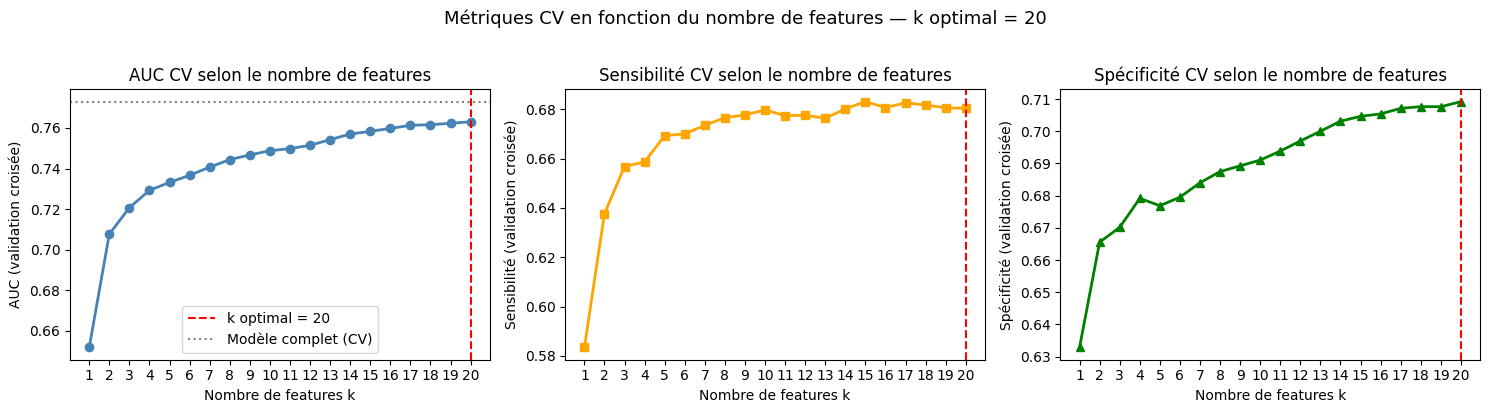

k optimal : 20 features
AUC CV    : 0.7631  (modèle complet CV : 0.773)

Features sélectionnées :
   1. EXT_SOURCE_2
   2. EXT_SOURCE_3
   3. EXT_SOURCE_1
   4. RATIO_CREDIT_BIEN
   5. INSTALL_MANQUE_MOYEN
   6. CODE_GENDER_M
   7. DAYS_EMPLOYED
   8. AMT_ANNUITY
   9. FLAG_OWN_CAR
  10. CC_SOLDE_MOYEN
  11. BUREAU_JOURS_MOYEN
  12. POS_NB_MOIS
  13. AGE
  14. AMT_CREDIT
  15. BUREAU_DETTE_MOYENNE
  16. NAME_EDUCATION_TYPE_Higher_education
  17. PREV_NB_REFUSEES
  18. NAME_FAMILY_STATUS_Married
  19. DAYS_ID_PUBLISH
  20. BUREAU_NB_ACTIFS


In [15]:
# k optimal = celui qui maximise l'AUC CV
idx_optimal = df_resultats['auc_cv'].idxmax()
k_optimal   = int(df_resultats.loc[idx_optimal, 'k'])
auc_optimal = df_resultats.loc[idx_optimal, 'auc_cv']

# AUC du modèle complet (notebook 03, cross-val, 119 features) pour référence
# Valeur lue dans MLflow : AUC CV ≈ 0.773 (run lightgbm notebook 03)
AUC_MODELE_COMPLET_CV = 0.773

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Graphique 1 : AUC CV vs k ---
axes[0].plot(df_resultats['k'], df_resultats['auc_cv'],
             marker='o', color='steelblue', linewidth=2)
axes[0].axvline(k_optimal, color='red', linestyle='--', label=f'k optimal = {k_optimal}')
axes[0].axhline(AUC_MODELE_COMPLET_CV, color='gray', linestyle=':', label='Modèle complet (CV)')
axes[0].set_xlabel('Nombre de features k')
axes[0].set_ylabel('AUC (validation croisée)')
axes[0].set_title('AUC CV selon le nombre de features')
axes[0].legend()
axes[0].set_xticks(range(1, 21))

# --- Graphique 2 : Sensibilité CV vs k ---
axes[1].plot(df_resultats['k'], df_resultats['sensibilite_cv'],
             marker='s', color='orange', linewidth=2)
axes[1].axvline(k_optimal, color='red', linestyle='--')
axes[1].set_xlabel('Nombre de features k')
axes[1].set_ylabel('Sensibilité (validation croisée)')
axes[1].set_title('Sensibilité CV selon le nombre de features')
axes[1].set_xticks(range(1, 21))

# --- Graphique 3 : Spécificité CV vs k ---
axes[2].plot(df_resultats['k'], df_resultats['specificite_cv'],
             marker='^', color='green', linewidth=2)
axes[2].axvline(k_optimal, color='red', linestyle='--')
axes[2].set_xlabel('Nombre de features k')
axes[2].set_ylabel('Spécificité (validation croisée)')
axes[2].set_title('Spécificité CV selon le nombre de features')
axes[2].set_xticks(range(1, 21))

plt.suptitle(f'Métriques CV en fonction du nombre de features — k optimal = {k_optimal}',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/auc_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'k optimal : {k_optimal} features')
print(f'AUC CV    : {auc_optimal:.4f}  (modèle complet CV : {AUC_MODELE_COMPLET_CV:.3f})')
print(f'\nFeatures sélectionnées :')
for i, f in enumerate(df_resultats.loc[idx_optimal, 'features'], 1):
    print(f'  {i:>2}. {f}')

**Analyse :** La courbe AUC CV croît de façon **monotone sans plateau** de k=1 (0.652) à k=20 (0.763).
Il n'y a pas de coude visible : chaque feature supplémentaire améliore légèrement l'AUC.
C'est cohérent avec le profil d'importance SHAP qui décroît graduellement sans rupture nette.

Le k optimal est donc **k=20** — la totalité des features SHAP. En comparaison, le modèle
complet à 119 features obtient AUC CV = 0.773 : on perd seulement **0.010 d'AUC** en passant
de 119 à 20 features, soit une réduction de 83% du nombre de features pour 1.3% de perte de performance.

La sensibilité reste stable autour de **0.68** pour k ≥ 10, ce qui est rassurant pour la contrainte
métier (détecter les défauts est prioritaire).

## 5. Entraînement du modèle final et recalcul du seuil

On entraîne le modèle définitif sur tout X_train avec les k* features.

**Pourquoi recalculer le seuil et ne pas réutiliser 0.54 ?**
Le seuil 0.54 a été optimisé sur le modèle à 119 features. Avec k features différentes,
la distribution des probabilités prédites change — le seuil optimal change aussi.
Réutiliser 0.54 sans vérifier serait une erreur : on risquerait de surestimer ou sous-estimer
le taux de refus en production.

**Méthode :** on optimise le seuil sur les probabilités OOF (Out-Of-Fold) de la validation
croisée — ce sont des prédictions sur des données que le modèle n'a jamais vues pendant
son entraînement, ce qui donne une estimation propre du seuil optimal.

**Fonction de coût :** `coût = 10 × FN + FP` (un faux négatif coûte 10× plus qu'un faux positif).

Modèle final : 20 features
Features : ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'RATIO_CREDIT_BIEN', 'INSTALL_MANQUE_MOYEN', 'CODE_GENDER_M', 'DAYS_EMPLOYED', 'AMT_ANNUITY', 'FLAG_OWN_CAR', 'CC_SOLDE_MOYEN', 'BUREAU_JOURS_MOYEN', 'POS_NB_MOIS', 'AGE', 'AMT_CREDIT', 'BUREAU_DETTE_MOYENNE', 'NAME_EDUCATION_TYPE_Higher_education', 'PREV_NB_REFUSEES', 'NAME_FAMILY_STATUS_Married', 'DAYS_ID_PUBLISH', 'BUREAU_NB_ACTIFS']

Calcul des probabilités OOF pour optimisation du seuil...
Seuil optimal recalculé : 0.53  (ancien seuil modèle complet : 0.54)


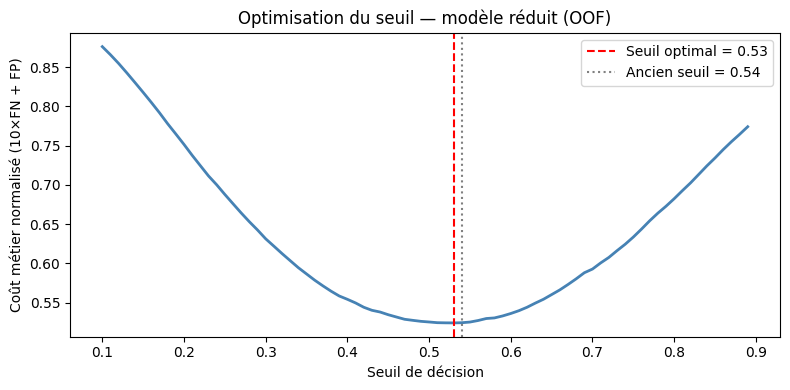

In [16]:
# Features et données du modèle final
features_finales  = df_resultats.loc[idx_optimal, 'features']
X_train_final     = X_train[features_finales]
X_test_final      = X_test[features_finales]

print(f'Modèle final : {k_optimal} features')
print('Features :', list(features_finales))

# --- Entraînement sur tout X_train ---
model_final = LGBMClassifier(**params_optimises)
model_final.fit(X_train_final, y_train)

# --- Optimisation du seuil sur les probabilités OOF ---
# On re-lance cross_val_predict pour obtenir les proba OOF (hors-échantillon)
# Ce sont les prédictions les plus propres pour calibrer le seuil :
# chaque client est prédit par un modèle qui ne l'a pas vu
print('\nCalcul des probabilités OOF pour optimisation du seuil...')
y_prob_oof = cross_val_predict(
    LGBMClassifier(**params_optimises),
    X_train_final, y_train,
    cv=cv, method='predict_proba'
)[:, 1]

# Balayage des seuils de 0.10 à 0.90 — calcul du coût métier pour chacun
seuils      = np.arange(0.10, 0.90, 0.01)
couts_seuil = []

for seuil in seuils:
    y_pred_s             = (y_prob_oof >= seuil).astype(int)
    tn, fp, fn, tp       = confusion_matrix(y_train, y_pred_s).ravel()
    cout_s               = (10 * fn + fp) / len(y_train)  # coût normalisé
    couts_seuil.append(cout_s)

# Seuil qui minimise le coût métier
SEUIL_OPTIMAL = round(seuils[np.argmin(couts_seuil)], 2)
print(f'Seuil optimal recalculé : {SEUIL_OPTIMAL}  (ancien seuil modèle complet : 0.54)')

# Courbe coût vs seuil
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(seuils, couts_seuil, color='steelblue', linewidth=2)
ax.axvline(SEUIL_OPTIMAL, color='red', linestyle='--',
           label=f'Seuil optimal = {SEUIL_OPTIMAL}')
ax.axvline(0.54, color='gray', linestyle=':', label='Ancien seuil = 0.54')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Coût métier normalisé (10×FN + FP)')
ax.set_title('Optimisation du seuil — modèle réduit (OOF)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/seuil_optimal_reduit.png', dpi=150, bbox_inches='tight')
plt.show()

--- Modèle réduit (20 features, seuil 0.53) ---
AUC test    : 0.7682
Sensibilité : 0.6548
Spécificité : 0.7459
Coût métier : 0.5123

                             Modèle   AUC  Sensibilité Spécificité Coût métier
Complet (119 features, seuil 0.54) 0.776        0.677           —           —
  Réduit (20 features, seuil 0.53) 0.768        0.655       0.746      0.5123


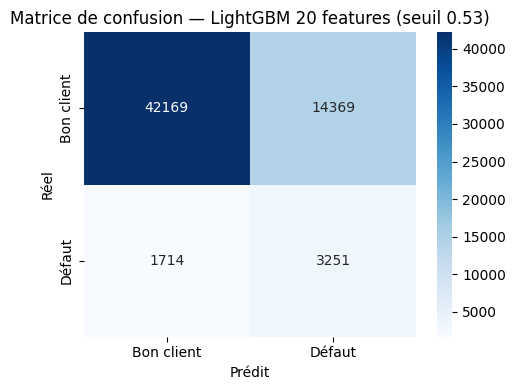

In [17]:
# Évaluation finale sur X_test avec le seuil recalculé
y_prob_test  = model_final.predict_proba(X_test_final)[:, 1]
y_pred_test  = (y_prob_test >= SEUIL_OPTIMAL).astype(int)

auc_test         = roc_auc_score(y_test, y_prob_test)
tn, fp, fn, tp   = confusion_matrix(y_test, y_pred_test).ravel()
sensibilite_test = tp / (tp + fn)
specificite_test = tn / (tn + fp)
cout_metier      = (10 * fn + fp) / len(y_test)

print(f'--- Modèle réduit ({k_optimal} features, seuil {SEUIL_OPTIMAL}) ---')
print(f'AUC test    : {auc_test:.4f}')
print(f'Sensibilité : {sensibilite_test:.4f}')
print(f'Spécificité : {specificite_test:.4f}')
print(f'Coût métier : {cout_metier:.4f}')

# Tableau comparatif — les valeurs du modèle complet viennent du notebook 04
comparaison = pd.DataFrame([
    {'Modèle': 'Complet (119 features, seuil 0.54)', 'AUC': 0.776, 'Sensibilité': 0.677, 'Spécificité': '—', 'Coût métier': '—'},
    {'Modèle': f'Réduit ({k_optimal} features, seuil {SEUIL_OPTIMAL})',
     'AUC': round(auc_test, 3), 'Sensibilité': round(sensibilite_test, 3),
     'Spécificité': round(specificite_test, 3), 'Coût métier': round(cout_metier, 4)}
])
print('\n', comparaison.to_string(index=False))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d',
            cmap='Blues', ax=ax,
            xticklabels=['Bon client', 'Défaut'],
            yticklabels=['Bon client', 'Défaut'])
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Matrice de confusion — LightGBM {k_optimal} features (seuil {SEUIL_OPTIMAL})')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_reduit.png', dpi=150, bbox_inches='tight')
plt.show()

**Analyse :** Le seuil optimal recalculé est **0.53** (contre 0.54 pour le modèle complet) —
très proche, ce qui indique que les distributions de probabilités sont similaires entre les deux modèles.
L'écart est faible mais pas nul : bien que peu impactant ici, recalculer le seuil est la bonne pratique
car rien ne garantit qu'il reste identique lors d'une réduction de features.

**Résultats finaux sur X_test (seuil 0.53) :**
- AUC = **0.768** (vs 0.776 modèle complet, -0.008)
- Sensibilité = **0.655** (vs 0.677, -0.022)
- Spécificité = **0.746**

La dégradation de la sensibilité (-0.022) mérite attention : sur 61 503 clients de test,
cela représente ~135 défauts supplémentaires non détectés. À mettre en regard du bénéfice :
20 features au lieu de 119 en production → requêtes API beaucoup plus simples, moins de données
à collecter, moins de risque d'erreur de saisie.

## 6. Sauvegarde et logging MLflow

On log le nouveau modèle dans MLflow comme version 2 du modèle `scoring-credit-lgbm`.
On sauvegarde aussi la liste des features sélectionnées — indispensable pour l'API
qui devra recevoir exactement ces k colonnes dans le bon ordre.

In [18]:
import json

# Sauvegarde de la liste des features sélectionnées (utilisée par l'API)
# L'ordre est important : l'API doit envoyer les features dans ce même ordre
features_dict = {'features': list(features_finales), 'k': k_optimal}
with open('../models/features_selectionnees.json', 'w') as f:
    json.dump(features_dict, f, indent=2)
print(f'Features sauvegardées dans models/features_selectionnees.json')

# Sauvegarde du modèle en pkl (pour l'API de production)
with open('../models/model_reduit.pkl', 'wb') as f:
    pickle.dump(model_final, f)
print(f'Modèle sauvegardé dans models/model_reduit.pkl')

Features sauvegardées dans models/features_selectionnees.json
Modèle sauvegardé dans models/model_reduit.pkl


In [19]:
import json

mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('scoring-credit')

with mlflow.start_run(run_name=f'lgbm_shap_{k_optimal}features'):

    mlflow.log_param('model',             'LightGBM_shap_reduit')
    mlflow.log_param('k_features',        k_optimal)
    mlflow.log_param('features',          json.dumps(list(features_finales)))
    mlflow.log_param('seuil_optimal',     SEUIL_OPTIMAL)
    mlflow.log_param('seuil_complet',     0.54)
    mlflow.log_param('learning_rate',     params_optimises['learning_rate'])
    mlflow.log_param('n_estimators',      params_optimises['n_estimators'])
    mlflow.log_param('num_leaves',        params_optimises['num_leaves'])
    mlflow.log_param('max_depth',         params_optimises['max_depth'])
    mlflow.log_param('min_child_samples', params_optimises['min_child_samples'])

    mlflow.log_metric('auc_test',          auc_test)
    mlflow.log_metric('auc_cv',            auc_optimal)
    mlflow.log_metric('sensibilite_test',  sensibilite_test)
    mlflow.log_metric('specificite_test',  specificite_test)
    mlflow.log_metric('cout_metier',       cout_metier)
    mlflow.log_metric('sensibilite_cv',    float(df_resultats.loc[idx_optimal, 'sensibilite_cv']))
    mlflow.log_metric('specificite_cv',    float(df_resultats.loc[idx_optimal, 'specificite_cv']))

    mlflow.log_artifact('../outputs/shap_importance_top20_selection.png', 'plots')
    mlflow.log_artifact('../outputs/auc_vs_k.png',                        'plots')
    mlflow.log_artifact('../outputs/seuil_optimal_reduit.png',            'plots')
    mlflow.log_artifact('../outputs/confusion_matrix_reduit.png',         'plots')
    mlflow.log_artifact('../models/features_selectionnees.json',          'features')

    mlflow.lightgbm.log_model(
        model_final,
        artifact_path='model',
        registered_model_name='scoring-credit-lgbm'
    )

    print(f'Run MLflow terminé — scoring-credit-lgbm v2')
    print(f'k={k_optimal} features | AUC={auc_test:.4f} | seuil={SEUIL_OPTIMAL}')

2026/05/08 11:12:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 11:12:25 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run MLflow terminé — scoring-credit-lgbm v2
k=20 features | AUC=0.7682 | seuil=0.53


Registered model 'scoring-credit-lgbm' already exists. Creating a new version of this model...
Created version '2' of model 'scoring-credit-lgbm'.


**Analyse :** Le modèle réduit est enregistré dans MLflow comme `scoring-credit-lgbm` **v2**.
Les deux artefacts clés pour l'API de production sont sauvegardés :
- `models/model_reduit.pkl` — le modèle LightGBM entraîné sur 20 features
- `models/features_selectionnees.json` — la liste ordonnée des 20 features et le seuil 0.53

L'API de production n'aura besoin que de ces 20 champs en entrée, contre 119 pour le modèle v1.
Le seuil de décision à utiliser est **0.53** (logué dans MLflow sous `seuil_optimal`).